# Administration-Specific Modeling

### Repeating Steps from Base Model
---

In [2]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Modeling
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Evaluation
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay, f1_score, accuracy_score
)

# Fairness
from sklearn.utils.class_weight import compute_sample_weight

# Visualization settings
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

BLUE   = "#1A237E"
PINK   = "#C2185B"
LIGHT  = "#F06292"
PALETTE = [BLUE, PINK, LIGHT, "#880E4F"]

In [4]:
df = pd.read_csv("../data/ICE_Master_Cleaned.csv", low_memory=False)
df.head()

,Stay Book In Date,Detention Book In Date,Detention Facility,Detention Book Out Date,Detention Release Reason,Stay Book Out Date,Stay Release Reason,Marital,Gender,Ethnicity,...,is_custodial_arrest,is_border_arrest,is_hispanic,is_male,is_PWA,is_asylum_seeker,has_criminal_charge,is_convicted,is_juvenile,State
0,2014-01-21,2014-01-21,Abilene Hold Room,2014-01-21,Voluntary Return,2014-01-21,Voluntary Return,Single,Male,Hispanic Origin,...,0,0,1,1,1,0,0,0,0,NaN
1,2014-01-22,2014-01-22,Abilene Hold Room,2014-01-22,Order Of Recognizance,2014-01-22,Order Of Recognizance,Single,Male,Hispanic Origin,...,0,0,1,1,1,0,0,0,0,NaN
2,2014-10-06,2014-10-06,Abilene Hold Room,2014-10-06,Order Of Recognizance,2014-10-06,Order Of Recognizance,Single,Male,Unknown,...,0,0,0,1,1,0,0,0,0,NaN
3,2014-09-15,2014-09-15,Abilene Hold Room,2014-09-15,Order Of Recognizance,2014-09-15,Order Of Recognizance,Single,Male,Unknown,...,0,0,0,1,1,0,0,0,0,NaN
4,2014-10-31,2014-10-31,Abilene Hold Room,2014-10-31,Transferred,2014-11-06,Bonded Out,Married,Male,Unknown,...,0,0,0,1,1,0,0,0,0,NaN


In [ ]:
# feature engineering
# Leaky / post-outcome columns to drop
LEAKY_COLS = [
    'Final Order Date',
    'Departed Date',
    'days_to_removal',
    'Departure Country',
    'Stay Book Out Date',
    'Stay Book In Date',       # redundant with year
    'Detention Book In Date',  # redundant with year
    'Detention Book Out Date', # use duration instead
    'Stay Release Reason',     # post-outcome
    'Detention Release Reason',# post-outcome
    'removals_Processing Disposition',  # post-outcome
    'State',                   # sparse / already captured by facility
    'Detention Facility',      # high cardinality — keep facility type instead
]

# Drop only if present
leaky_present = [c for c in LEAKY_COLS if c in df.columns]
model_df = df.drop(columns=leaky_present).copy()

# Additional engineered features
# Repeat detention: flag if this is not their first detention
model_df['is_repeat_detention'] = (model_df['running_detention_count'] > 1).astype(int)

# Prior removal: flag if they have been removed before
model_df['has_prior_removal'] = (model_df['running_removal_count'] > 0).astype(int)

# Prior arrest: flag if they have prior arrests
model_df['has_prior_arrest'] = (model_df['running_arrest_count'] > 1).astype(int)

# Age group buckets (more stable than raw age)
def age_group(age):
    if pd.isna(age):
        return 'Unknown'
    elif age < 18:
        return 'Juvenile'
    elif age < 26:
        return 'Young Adult'
    elif age < 40:
        return 'Adult'
    elif age < 56:
        return 'Middle Aged'
    else:
        return 'Senior'

model_df['age_group'] = model_df['age_at_detention'].apply(age_group)

# Detention duration bucket
def detention_bucket(days):
    if pd.isna(days):
        return 'Unknown'
    elif days == 0:
        return 'Same Day'
    elif days <= 7:
        return '1 Week'
    elif days <= 30:
        return '1 Month'
    elif days <= 90:
        return '3 Months'
    else:
        return 'Long Term'

model_df['detention_bucket'] = model_df['detention_duration_days'].apply(detention_bucket)

print(f"Model dataframe shape: {model_df.shape}")
print(f"\nNew features added: is_repeat_detention, has_prior_removal, has_prior_arrest, age_group, detention_bucket")
print(f"\nMissing values summary:")
missing = model_df.isna().sum()
print(missing[missing > 0].sort_values(ascending=False))

Model dataframe shape: (749491, 39)

New features added: is_repeat_detention, has_prior_removal, has_prior_arrest, age_group, detention_bucket

Missing values summary:
detention_duration_days    14976
age_at_detention             498
dtype: int64


### Creating Administration Subsets
---

In [ ]:
cols_to_export = model_df.columns.tolist()  # all columns

for admin in ['Obama', 'Trump', 'Biden']:
    subset = model_df[model_df['administration'] == admin][cols_to_export]
    print(f"--- Head of {admin} subset ({len(subset)} rows) ---")
    display(subset.head())  # show first 5 rows in Jupyter

    # code to download subsets as CSV files
    # filename = f"ICE_{admin}_subset_modeling.csv"
    # subset.to_csv(filename, index=False)
    # print(f"Saved {filename}\n")

--- Head of Obama subset (247555 rows) ---


,Marital,Gender,Ethnicity,Birth Year,Entry Status,Case Status,Case Category,Case Threat Level,days_to_stay,running_arrest_count,...,is_PWA,is_asylum_seeker,has_criminal_charge,is_convicted,is_juvenile,is_repeat_detention,has_prior_removal,has_prior_arrest,age_group,detention_bucket
0,Single,Male,Hispanic Origin,1977.0,Pwa Mexico,Active,[9] Vr Under Safeguards,3.0,0.0,1,...,1,0,0,0,0,0,0,0,Adult,Same Day
1,Single,Male,Hispanic Origin,1985.0,Pwa Mexico,Active,[8C] Excludable / Inadmissible - Administrativ...,Unknown,0.0,1,...,1,0,0,0,0,0,0,0,Adult,Same Day
2,Single,Male,Unknown,1989.0,Pwa Mexico,Active,[8A] Excludable / Inadmissible - Hearing Not C...,Unknown,0.0,0,...,1,0,0,0,0,0,0,0,Young Adult,Same Day
3,Single,Male,Unknown,1977.0,Pwa Mexico,Active,[8A] Excludable / Inadmissible - Hearing Not C...,Unknown,0.0,0,...,1,0,0,0,0,0,0,0,Adult,Same Day
4,Married,Male,Unknown,1969.0,Pwa Mexico,3-Voluntary Departure Confirmed,[8C] Excludable / Inadmissible - Administrativ...,2.0,0.0,0,...,1,0,0,0,0,0,0,0,Middle Aged,Same Day


Saved ICE_Obama_subset_modeling.csv

--- Head of Trump subset (302241 rows) ---


,Marital,Gender,Ethnicity,Birth Year,Entry Status,Case Status,Case Category,Case Threat Level,days_to_stay,running_arrest_count,...,is_PWA,is_asylum_seeker,has_criminal_charge,is_convicted,is_juvenile,is_repeat_detention,has_prior_removal,has_prior_arrest,age_group,detention_bucket
12,Single,Male,Unknown,2011.0,Pwa Mexico,Active,[8B] Excludable / Inadmissible - Under Adjudic...,Unknown,0.0,0,...,1,0,0,0,1,0,0,0,Juvenile,Same Day
13,Single,Male,Hispanic Origin,2001.0,Unknown,8-Excluded/Removed - Inadmissibility,[8C] Excludable / Inadmissible - Administrativ...,Unknown,0.0,1,...,0,0,0,0,1,0,1,0,Juvenile,Long Term
16,Single,Male,Unknown,1998.0,Unknown,Active,[8D] Excludable / Inadmissible - Under Adjudic...,Unknown,0.0,1,...,0,0,0,0,0,0,0,0,Adult,Unknown
22,Unknown,Male,Hispanic Origin,1956.0,Not Applicable,Active,[1A] Voluntary Departure - Un-Expired And Un-E...,Unknown,0.0,1,...,0,0,0,0,0,0,0,0,Senior,1 Month
31,Single,Male,Unknown,1983.0,Immigrant,Active,[16] Reinstated Final Order,3.0,0.0,0,...,0,0,0,0,0,0,0,0,Middle Aged,1 Week


Saved ICE_Trump_subset_modeling.csv

--- Head of Biden subset (199695 rows) ---


,Marital,Gender,Ethnicity,Birth Year,Entry Status,Case Status,Case Category,Case Threat Level,days_to_stay,running_arrest_count,...,is_PWA,is_asylum_seeker,has_criminal_charge,is_convicted,is_juvenile,is_repeat_detention,has_prior_removal,has_prior_arrest,age_group,detention_bucket
17,Single,Male,Unknown,1986.0,Pwa Mexico,Active,"B(6), B(7)C",Unknown,0.0,0,...,1,0,0,0,0,0,0,0,Adult,3 Months
18,Unknown,Male,Unknown,1992.0,Pwa Mexico,Active,"B(6), B(7)C",Unknown,0.0,0,...,1,0,0,0,0,0,0,0,Adult,3 Months
19,Single,Male,Unknown,1993.0,Pwa Mexico,Active,"B(6), B(7)C",Unknown,0.0,0,...,1,0,0,0,0,0,0,0,Adult,3 Months
20,Unknown,Male,Unknown,1991.0,Pwa Mexico,Active,"B(6), B(7)C",Unknown,0.0,0,...,1,0,0,0,0,0,0,0,Adult,3 Months
21,Unknown,Male,Unknown,1987.0,Pwa Mexico,Active,[8B] Excludable / Inadmissible - Under Adjudic...,Unknown,0.0,0,...,1,0,0,0,0,0,0,0,Adult,3 Months


Saved ICE_Biden_subset_modeling.csv



### Modeling
---

In [10]:
# importing obama subset for modeling
obama_df = pd.read_csv("../data/ICE_Obama_subset_modeling.csv")
print(f"Obama subset shape: {obama_df.shape}")
obama_df.head()

Obama subset shape: (247555, 39)


,Marital,Gender,Ethnicity,Birth Year,Entry Status,Case Status,Case Category,Case Threat Level,days_to_stay,running_arrest_count,...,is_PWA,is_asylum_seeker,has_criminal_charge,is_convicted,is_juvenile,is_repeat_detention,has_prior_removal,has_prior_arrest,age_group,detention_bucket
0,Single,Male,Hispanic Origin,1977.0,Pwa Mexico,Active,[9] Vr Under Safeguards,3.0,0.0,1,...,1,0,0,0,0,0,0,0,Adult,Same Day
1,Single,Male,Hispanic Origin,1985.0,Pwa Mexico,Active,[8C] Excludable / Inadmissible - Administrativ...,Unknown,0.0,1,...,1,0,0,0,0,0,0,0,Adult,Same Day
2,Single,Male,Unknown,1989.0,Pwa Mexico,Active,[8A] Excludable / Inadmissible - Hearing Not C...,Unknown,0.0,0,...,1,0,0,0,0,0,0,0,Young Adult,Same Day
3,Single,Male,Unknown,1977.0,Pwa Mexico,Active,[8A] Excludable / Inadmissible - Hearing Not C...,Unknown,0.0,0,...,1,0,0,0,0,0,0,0,Adult,Same Day
4,Married,Male,Unknown,1969.0,Pwa Mexico,3-Voluntary Departure Confirmed,[8C] Excludable / Inadmissible - Administrativ...,2.0,0.0,0,...,1,0,0,0,0,0,0,0,Middle Aged,Same Day


In [11]:
# importing trump subset for modeling
trump_df = pd.read_csv("../data/ICE_Trump_subset_modeling.csv")
print(f"Trump subset shape: {trump_df.shape}")
trump_df.head()

Trump subset shape: (302241, 39)


,Marital,Gender,Ethnicity,Birth Year,Entry Status,Case Status,Case Category,Case Threat Level,days_to_stay,running_arrest_count,...,is_PWA,is_asylum_seeker,has_criminal_charge,is_convicted,is_juvenile,is_repeat_detention,has_prior_removal,has_prior_arrest,age_group,detention_bucket
0,Single,Male,Unknown,2011.0,Pwa Mexico,Active,[8B] Excludable / Inadmissible - Under Adjudic...,Unknown,0.0,0,...,1,0,0,0,1,0,0,0,Juvenile,Same Day
1,Single,Male,Hispanic Origin,2001.0,Unknown,8-Excluded/Removed - Inadmissibility,[8C] Excludable / Inadmissible - Administrativ...,Unknown,0.0,1,...,0,0,0,0,1,0,1,0,Juvenile,Long Term
2,Single,Male,Unknown,1998.0,Unknown,Active,[8D] Excludable / Inadmissible - Under Adjudic...,Unknown,0.0,1,...,0,0,0,0,0,0,0,0,Adult,Unknown
3,Unknown,Male,Hispanic Origin,1956.0,Not Applicable,Active,[1A] Voluntary Departure - Un-Expired And Un-E...,Unknown,0.0,1,...,0,0,0,0,0,0,0,0,Senior,1 Month
4,Single,Male,Unknown,1983.0,Immigrant,Active,[16] Reinstated Final Order,3.0,0.0,0,...,0,0,0,0,0,0,0,0,Middle Aged,1 Week


In [ ]:
# feature sets from base model (shared across both adminnistration models)
TARGET = 'final_order_numeric'

# Binary features (no encoding needed)
BINARY_FEATURES = [
    'is_CAP_arrest', 'is_287g_arrest', 'is_custodial_arrest', 'is_border_arrest',
    'is_hispanic', 'is_male', 'is_PWA', 'is_asylum_seeker',
    'has_criminal_charge', 'is_convicted', 'is_juvenile',
    'is_repeat_detention', 'has_prior_removal', 'has_prior_arrest',
]
# Only keep binary features that exist
BINARY_FEATURES = [f for f in BINARY_FEATURES if f in model_df.columns]

# Numeric features
NUMERIC_FEATURES = [
    'age_at_detention',
    'detention_duration_days',
    'running_arrest_count',
    'running_detention_count',
    'running_removal_count',
    'year',
]
NUMERIC_FEATURES = [f for f in NUMERIC_FEATURES if f in model_df.columns]

# Categorical features
CATEGORICAL_FEATURES = [
    'administration',
    'Case Category',
    'Case Status',
    'Case Threat Level',
    'Entry Status',
    'Gender',
    'Ethnicity',
    'Marital',
    'arrests_Apprehension Method',
    'removals_MSC Charge',
    'removals_MSC Criminal Charge Status',
    'removals_Current Program',
    'removals_Birth Country',
    'removals_Citizenship Country',
    'age_group',
    'detention_bucket',
]

CATEGORICAL_FEATURES = [f for f in CATEGORICAL_FEATURES if f != 'administration']
ALL_FEATURES = BINARY_FEATURES + NUMERIC_FEATURES + CATEGORICAL_FEATURES

print(f"Binary features  : {len(BINARY_FEATURES)}")
print(f"Numeric features : {len(NUMERIC_FEATURES)}")
print(f"Categorical feats: {len(CATEGORICAL_FEATURES)}")
print(f"Total features   : {len(ALL_FEATURES)}")

Binary features  : 14
Numeric features : 6
Categorical feats: 15
Total features   : 35


### Shared Functions for Models
---

In [16]:
def build_pipeline(clf, binary_features, numeric_features, categorical_features):
    """
    Builds a full sklearn Pipeline with ColumnTransformer preprocessing:
      - Binary : passthrough (already 0/1)
      - Numeric: median imputation → StandardScaler
      - Categorical: constant imputation → OneHotEncoder
    """
    # Filter to only columns that exist in data (safety check)
    binary_present      = [f for f in binary_features      if f in obama_df.columns]
    numeric_present     = [f for f in numeric_features     if f in obama_df.columns]
    categorical_present = [f for f in categorical_features if f in obama_df.columns]

    preprocessor = ColumnTransformer(transformers=[
        ('binary', 'passthrough', binary_present),
        ('numeric', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler',  StandardScaler()),
        ]), numeric_present),
        ('categorical', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
        ]), categorical_present),
    ], remainder='drop')

    return Pipeline([
        ('preprocessor', preprocessor),
        ('classifier',   clf),
    ])


def evaluate_model(pipeline, X_test, y_test, model_name, admin_name):
    """Prints classification report and returns a summary dict."""
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1] if hasattr(pipeline, 'predict_proba') else None

    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan
    ap   = average_precision_score(y_test, y_prob) if y_prob is not None else np.nan

    print(f"\n{'='*55}")
    print(f"  {admin_name} | {model_name}")
    print(f"{'='*55}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  F1       : {f1:.4f}")
    print(f"  ROC-AUC  : {auc:.4f}")
    print(f"  Avg Prec : {ap:.4f}")
    print(classification_report(y_test, y_pred, zero_division=0))

    return {'administration': admin_name, 'model': model_name,
            'accuracy': acc, 'f1': f1, 'roc_auc': auc, 'avg_precision': ap}


def plot_confusion_matrix(pipeline, X_test, y_test, model_name, admin_name, color):
    """Plots a styled confusion matrix."""
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_estimator(
        pipeline, X_test, y_test,
        colorbar=False, cmap=plt.cm.Blues, ax=ax
    )
    ax.set_title(f"{admin_name} — {model_name}\nConfusion Matrix")
    plt.tight_layout()
    plt.show()


def plot_roc_curves(pipelines_dict, X_test, y_test, admin_name):
    """Overlays ROC curves for all models on a single plot."""
    fig, ax = plt.subplots(figsize=(6, 5))
    colors = PALETTE[:len(pipelines_dict)]

    for (name, pipeline), color in zip(pipelines_dict.items(), colors):
        y_prob = pipeline.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc = roc_auc_score(y_test, y_prob)
        ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=color, lw=2)

    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set(xlabel='False Positive Rate', ylabel='True Positive Rate',
           title=f"{admin_name} — ROC Curves")
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()


def get_feature_importances(pipeline, top_n=20):
    """Extracts feature importances from a tree-based Pipeline."""
    clf = pipeline.named_steps['classifier']
    if not hasattr(clf, 'feature_importances_'):
        return None

    # Reconstruct feature names from ColumnTransformer
    ct = pipeline.named_steps['preprocessor']
    feature_names = []
    for name, transformer, cols in ct.transformers_:
        if transformer == 'passthrough':
            feature_names.extend(cols)
        elif hasattr(transformer, 'steps'):
            last_step = transformer.steps[-1][1]
            if hasattr(last_step, 'get_feature_names_out'):
                feature_names.extend(last_step.get_feature_names_out(cols))
            else:
                feature_names.extend(cols)

    importances = pd.Series(clf.feature_importances_, index=feature_names)
    return importances.nlargest(top_n)


def plot_feature_importances(importances, model_name, admin_name, color):
    """Horizontal bar chart of top feature importances."""
    fig, ax = plt.subplots(figsize=(8, 5))
    importances.sort_values().plot(kind='barh', ax=ax, color=color)
    ax.set_title(f"{admin_name} — {model_name}\nTop Feature Importances")
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.show()

In [17]:
# Fairness Utility Functions

def compute_fairness_metrics(y_true, y_pred, group_mask, group_name):
    """
    Computes group-level fairness metrics for a binary sensitive attribute.

    Returns a dict with:
      - Positive Prediction Rate (PPR)  → Demographic Parity
      - True Positive Rate (TPR)        → Equal Opportunity
      - False Positive Rate (FPR)       → Predictive Equality
      - False Negative Rate (FNR)
      - Precision
    """
    results = {}
    for label, mask in [('group_1', group_mask), ('group_0', ~group_mask)]:
        yt = y_true[mask]
        yp = y_pred[mask]
        if len(yt) == 0:
            continue
        tp = ((yt == 1) & (yp == 1)).sum()
        fp = ((yt == 0) & (yp == 1)).sum()
        tn = ((yt == 0) & (yp == 0)).sum()
        fn = ((yt == 1) & (yp == 0)).sum()

        results[label] = {
            'n':         len(yt),
            'PPR':       yp.mean(),                          # P(ŷ=1)
            'TPR':       tp / (tp + fn) if (tp + fn) > 0 else np.nan,
            'FPR':       fp / (fp + tn) if (fp + tn) > 0 else np.nan,
            'FNR':       fn / (tp + fn) if (tp + fn) > 0 else np.nan,
            'Precision': tp / (tp + fp) if (tp + fp) > 0 else np.nan,
        }
    return results


def fairness_report(pipeline, X_test, y_test, sensitive_cols, admin_name, model_name):
    """
    Runs fairness analysis over multiple sensitive attributes and returns
    a tidy DataFrame with disparity gaps for each group / metric.

    sensitive_cols: dict  {display_label: column_name_in_X_test}
                    e.g. {'Hispanic': 'is_hispanic', 'Male': 'is_male'}
    """
    y_pred = pipeline.predict(X_test)
    X_reset = X_test.reset_index(drop=True)
    y_reset = y_test.reset_index(drop=True)
    y_pred_s = pd.Series(y_pred)

    records = []
    for label, col in sensitive_cols.items():
        if col not in X_reset.columns:
            print(f"  [skip] '{col}' not in test set")
            continue
        group_mask = X_reset[col].astype(bool)
        metrics = compute_fairness_metrics(y_reset, y_pred_s, group_mask, label)

        for metric in ['PPR', 'TPR', 'FPR', 'FNR', 'Precision']:
            g1  = metrics.get('group_1', {}).get(metric, np.nan)
            g0  = metrics.get('group_0', {}).get(metric, np.nan)
            gap = g1 - g0
            records.append({
                'administration': admin_name,
                'model':          model_name,
                'attribute':      label,
                'metric':         metric,
                f'{label}=1':     round(g1,  4),
                f'{label}=0':     round(g0,  4),
                'gap (1 - 0)':    round(gap, 4),
            })

    return pd.DataFrame(records)


def plot_fairness_gaps(fairness_df, admin_name, model_name, color):
    """Bar chart of fairness disparity gaps across attributes and metrics."""
    df_plot = fairness_df.copy()
    df_plot['label'] = df_plot['attribute'] + ' | ' + df_plot['metric']

    fig, ax = plt.subplots(figsize=(9, max(4, len(df_plot) * 0.35)))
    colors = [PINK if v > 0 else BLUE for v in df_plot['gap (1 - 0)']]
    ax.barh(df_plot['label'], df_plot['gap (1 - 0)'], color=colors)
    ax.axvline(0, color='black', lw=0.8, linestyle='--')
    ax.set_title(f"{admin_name} — {model_name}\nFairness Disparity Gaps (group=1 minus group=0)")
    ax.set_xlabel("Gap")
    plt.tight_layout()
    plt.show()


# Sensitive attributes to evaluate (column must exist in X_test)
SENSITIVE_COLS = {
    'Hispanic':       'is_hispanic',
    'Male':           'is_male',
    'Asylum Seeker':  'is_asylum_seeker',
    'Criminal Charge':'has_criminal_charge',
    'Juvenile':       'is_juvenile',
    'Border Arrest':  'is_border_arrest',
}

### Obama Model
---

In [18]:
# Obama: Data Preparation
obama_features = [f for f in ALL_FEATURES if f in obama_df.columns]

X_obama = obama_df[obama_features]
y_obama = obama_df[TARGET]

# Drop rows where target is missing
valid_mask = y_obama.notna()
X_obama, y_obama = X_obama[valid_mask], y_obama[valid_mask]

X_train_ob, X_test_ob, y_train_ob, y_test_ob = train_test_split(
    X_obama, y_obama, test_size=0.2, random_state=42, stratify=y_obama
)

# Class weights to handle imbalance
sample_weights_ob = compute_sample_weight('balanced', y_train_ob)

print(f"Obama — Train: {X_train_ob.shape}, Test: {X_test_ob.shape}")
print(f"Target distribution:\n{y_obama.value_counts(normalize=True).round(3)}")

Obama — Train: (198044, 35), Test: (49511, 35)
Target distribution:
final_order_numeric
1    0.746
0    0.254
Name: proportion, dtype: float64



  Obama | Logistic Regression
  Accuracy : 0.9660
  F1       : 0.9768
  ROC-AUC  : 0.9942
  Avg Prec : 0.9978
              precision    recall  f1-score   support

           0       0.89      0.98      0.94     12556
           1       0.99      0.96      0.98     36955

    accuracy                           0.97     49511
   macro avg       0.94      0.97      0.96     49511
weighted avg       0.97      0.97      0.97     49511



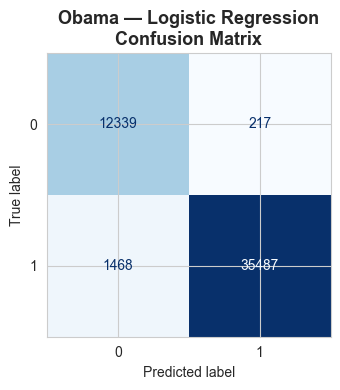

In [19]:
# Obama: Logistic Regression
obama_bin_feats = [f for f in BINARY_FEATURES      if f in obama_df.columns]
obama_num_feats = [f for f in NUMERIC_FEATURES     if f in obama_df.columns]
obama_cat_feats = [f for f in CATEGORICAL_FEATURES if f in obama_df.columns]

lr_ob = build_pipeline(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    obama_bin_feats, obama_num_feats, obama_cat_feats
)
lr_ob.fit(X_train_ob, y_train_ob)

ob_lr_results = evaluate_model(lr_ob, X_test_ob, y_test_ob, 'Logistic Regression', 'Obama')
plot_confusion_matrix(lr_ob, X_test_ob, y_test_ob, 'Logistic Regression', 'Obama', BLUE)


  Obama | Decision Tree
  Accuracy : 0.9634
  F1       : 0.9750
  ROC-AUC  : 0.9839
  Avg Prec : 0.9918
              precision    recall  f1-score   support

           0       0.88      0.99      0.93     12556
           1       0.99      0.96      0.97     36955

    accuracy                           0.96     49511
   macro avg       0.94      0.97      0.95     49511
weighted avg       0.97      0.96      0.96     49511



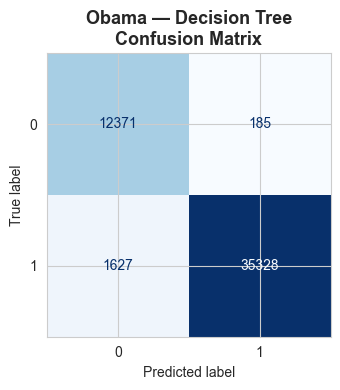

ValueError: Length of values (912) does not match length of index (898)

In [21]:
# Obama: Decision Tree
dt_ob = build_pipeline(
    DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=42),
    obama_bin_feats, obama_num_feats, obama_cat_feats
)
dt_ob.fit(X_train_ob, y_train_ob)

ob_dt_results = evaluate_model(dt_ob, X_test_ob, y_test_ob, 'Decision Tree', 'Obama')
plot_confusion_matrix(dt_ob, X_test_ob, y_test_ob, 'Decision Tree', 'Obama', BLUE)

imp = get_feature_importances(dt_ob)
if imp is not None:
    plot_feature_importances(imp, 'Decision Tree', 'Obama', BLUE)


  Obama | Random Forest
  Accuracy : 0.8948
  F1       : 0.9252
  ROC-AUC  : 0.9842
  Avg Prec : 0.9947
              precision    recall  f1-score   support

           0       0.72      0.97      0.82     12556
           1       0.99      0.87      0.93     36955

    accuracy                           0.89     49511
   macro avg       0.85      0.92      0.87     49511
weighted avg       0.92      0.89      0.90     49511



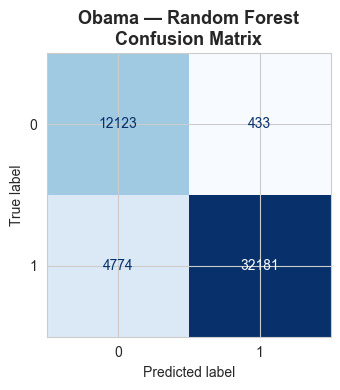

ValueError: Length of values (912) does not match length of index (898)

In [22]:
# ── Obama: Random Forest ───────────────────────────────────────────────────
rf_ob = build_pipeline(
    RandomForestClassifier(
        n_estimators=200, max_depth=12,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    obama_bin_feats, obama_num_feats, obama_cat_feats
)
rf_ob.fit(X_train_ob, y_train_ob)

ob_rf_results = evaluate_model(rf_ob, X_test_ob, y_test_ob, 'Random Forest', 'Obama')
plot_confusion_matrix(rf_ob, X_test_ob, y_test_ob, 'Random Forest', 'Obama', BLUE)

imp = get_feature_importances(rf_ob)
if imp is not None:
    plot_feature_importances(imp, 'Random Forest', 'Obama', BLUE)

### Trump Model
---